In [1]:
# 6 — Score a real run (.npz)

import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath("../.."))

from analysis.scoring import (
    scoring_input_from_npz,
    score_2d,
    score_run,
    hex_gridness_2d,
    global_order_1cell,
    autocorrelation_1cell,
)
from analysis.prototypes import reference_scores

Load and inspect the file

In [5]:
PROJECT_ROOT = Path(os.path.abspath("../.."))  # same anchor as sys.path insert
RUN = PROJECT_ROOT / "notebooks/path_integration/runs/arena2d_T20000_kap10.0_seed0.npz"

d  = np.load(RUN)
wp = d["world_pos"]
S  = d["S_tot_buffer"]
v = d["v_body_seq"]                       # (T, 3) — THIS is the array
T  = len(wp)
step = np.median(np.linalg.norm(np.diff(wp[:, :2], axis=0), axis=1))

print(f"keys        : {list(d.files)}")
print(f"world_pos   : {wp.shape}   S_tot_buffer: {S.shape}  (T={T}, {S.shape[1]} cells)")
print(f"x range     : [{wp[:,0].min():.3f}, {wp[:,0].max():.3f}]")
print(f"y range     : [{wp[:,1].min():.3f}, {wp[:,1].max():.3f}]")
print(f"z std (flat run or not): {wp[:,2].std():.3e}")
print(f"median step : {step:.4f}")

keys        : ['world_pos', 'v_body_seq', 'torus_gt', 'theta_hist', 'n_hat_hist', 'gap_hist', 'norm_error', 'S_tot_buffer']
world_pos   : (20000, 3)   S_tot_buffer: (20000, 9261)  (T=20000, 9261 cells)
x range     : [-1.000, 1.000]
y range     : [-1.000, 0.999]
z std (flat run or not): 0.000e+00
median step : 0.0032


In [6]:
si = scoring_input_from_npz(RUN, n_neuron=5000, norm="divmax")
print(f"active cells : {si.meta['n_active']}/{si.meta['n_total']} "
      f"(dead/flat traces dropped before scoring)")

active cells : 2205/9261 (dead/flat traces dropped before scoring)


Check if we have grid in the spesific run

In [ ]:
out = score_2d(RUN, n_neuron=5000, norm="minmax")
hgs, sgs = out["hgs"], out["sgs"]
grid_like = np.isfinite(hgs) & (hgs > 0.3) & (sgs < hgs)
n_act = out["f"].shape[-1]

print(f"occupancy: {out['occupancy']:.0%}   (low coverage -> weak rings; T={T} is short)")
print(f"ring detected: {out['ring_frac']:.0%} of active cells")
print(f"grid-like cells: {grid_like.sum()}/{n_act}  (HGS > 0.3 and SGS < HGS)")
if np.isfinite(hgs).any():
    print(f"median HGS (all) : {np.nanmedian(hgs):.2f}   "
              f"median HGS (grid-like): {np.nanmedian(hgs[grid_like]) if grid_like.any() else float('nan'):.2f}")
verdict = ("PASS — the CAN produces hexagonal grids; a later 3D floor would be meaningful"
               if grid_like.mean() > 0.3 else
               "WEAK a few grid-like cells; check the network/tuning (or the short trajectory) "
               "before trusting any 3D result")
print(f"\nBASELINE VERDICT : {verdict}")

occupancy        : 57%   (low coverage -> weak rings; T=20000 is short)
ring detected    : 91% of active cells
grid-like cells  : 93/2205  (HGS > 0.3 and SGS < HGS)
median HGS (all) : -0.00   median HGS (grid-like): 0.43

BASELINE VERDICT : WEAK — few grid-like cells; check the network/tuning (or the short trajectory) before trusting any 3D result


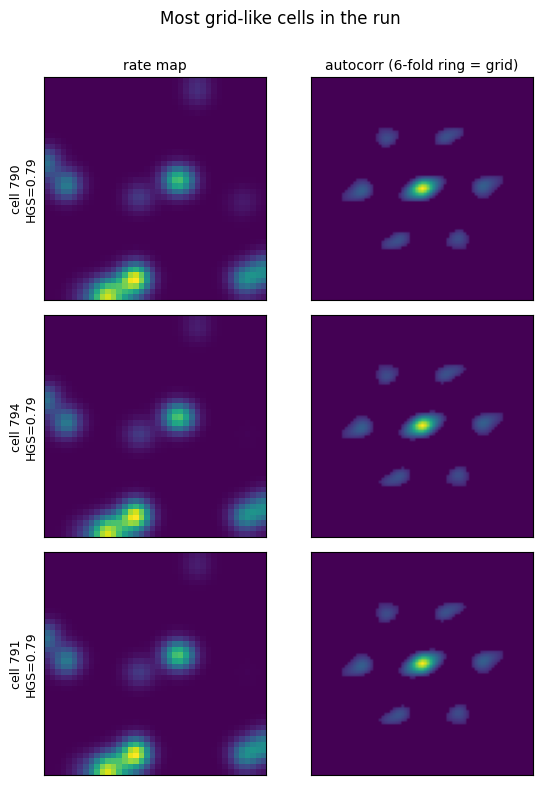

In [9]:
# show the most grid-like cells: rate map + autocorrelogram
order = np.argsort(np.where(np.isfinite(hgs), hgs, -np.inf))[::-1][:3]
fig, axes = plt.subplots(len(order), 2, figsize=(6, 2.6 * len(order)))
axes = np.atleast_2d(axes)
for row, k in enumerate(order):
    axes[row, 0].imshow(out["f"][..., k].T, origin="lower", cmap="viridis")
    axes[row, 0].set_ylabel(f"cell {k}\nHGS={hgs[k]:.2f}", fontsize=9)
    axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
    axes[row, 1].imshow(out["ac"][..., k].T, origin="lower", cmap="viridis")
    axes[row, 1].set_xticks([]); axes[row, 1].set_yticks([])
    if row == 0:
        axes[row, 0].set_title("rate map", fontsize=10)
        axes[row, 1].set_title("autocorr (6-fold ring = grid)", fontsize=10)

plt.suptitle("Most grid-like cells in the run", y=1.001)
plt.tight_layout(); plt.show()